### Importing required libraries...

In [1]:
import re
import os
import numpy as np
from astropy.io import ascii
from astropy.io import fits
from astropy.table import Table
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
from io import StringIO
from matplotlib.ticker import AutoMinorLocator
from astropy.constants import L_sun
from matplotlib import gridspec
import astropy.units as u
from math import pi
import gc
from matplotlib.ticker import ScalarFormatter

### Defining global variables

In [2]:
global home
global name
global hdr_params
global hdr_titles
global cat_line

### Names of the varibles given by STARLIGHT output

In [3]:
hdr_params = ["[arq_obs]","[arq_base]","[arq_masks]","[arq_config]","[N_base]","[N_YAV_components = # of components with extra extinction!]",
              "[i_FitPowerLaw (1/0 = Yes/No)]","[alpha_PowerLaw]","[red_law_option]","[q_norm = A(l_norm)/A(V)]", ## Some input info
              
              "[l_ini (A)]","[l_fin (A)]","[dl    (A)]     (OBS: dl_cushion =    50.00 A)", ## (Re)Sampling Parameters

              "[l_norm (A) - for base]","[llow_norm (A) - window for f_obs]","[lupp_norm (A) - window for f_obs]","[fobs_norm (in input units)]", ## Normalization info
              
              "[llow_SN (A) - window for S/N]","[lupp_SN (A) - window for S/N]","[S/N in S/N window]","[S/N in norm. window]","[S/N_err in S/N window]",
              "[S/N_err in norm. window]","[fscale_chi2]", ## S/N

              "[idum_orig]","[NOl_eff]","[Nl_eff]","[Ntot_cliped & clip_method]","[Nglobal_steps]","[N_chains]","[NEX0s_base = N_base in EX0s-fits]",
              "[Clip-Bug, RC-Crash & Burn-In warning-flags, n_censored_weights, wei_nsig_threshold & wei_limit]",
              "[idt_all, wdt_TotTime, wdt_UsrTime & wdt_SysTime (sec)]", ## etc...

              "[chi2/Nl_eff]","[adev (%)]","[sum-of-x (%)]","[Flux_tot (units of input spectrum!)]","[Mini_tot (???)]","[Mcor_tot (???)]",
              "[v0_min  (km/s)]","[vd_min  (km/s)]","[AV_min  (mag)]","[YAV_min (mag)]", ## Synthesis Results - Best model ##
              ]

hdr_titles = ['## OUTPUT of StarlightChains_v05.for    [Cid@UFSC - 10/May/2008] ##',
              "## Some input info", 
              "## (Re)Sampling Parameters", 
              "## Normalization info", 
              "## S/N",
              "## etc...",
              "## Synthesis Results - Best model ##"]

cat_line = '#' *67

### Fuctions defined for string management and reading data ...

In [4]:
def get_first_value(line: str):
    """
    Devuelve el primer valor no vacío de un string.
    - Si solo hay espacios: devuelve 'No data'
    - Si el valor es número entero/float (incluyendo notación científica): devuelve número
    - Si no se puede convertir: devuelve string
    """
    tokens = line.strip().split()
    if not tokens:   # Caso: línea solo con espacios
        return "NoData"
    
    token = tokens[0]
    # Intentar convertir a número
    try:
        val = int(token)
        return val
    except ValueError:
        try:
            val = float(token)
            return val
        except ValueError:
            return token
        
def parse_before_brackets(line: str):
    """
    Devuelve los valores antes de los corchetes.
    Ejemplo: "895    NSIGMA   [..]" -> ["895", "NSIGMA"]
    """
    # separar la parte antes de los corchetes
    before = re.split(r'\[', line.strip(), maxsplit=1)[0]
    # dividir en tokens por espacios
    tokens = before.split()
    return tokens

### Header for the First Table creation ...

In [5]:
def header_firstTABLE(name):
    HDR = fits.Header()
    with open(name, 'r') as file:
        c = 0
        for line in file:
            v = get_first_value(line) 
            if v ==cat_line:
                #HDR.add_comment(cat_line)
                HDR.insert(c, ('COMMENT',cat_line))
            if v == "##":
                for i in hdr_titles:
                    if (i in line):
                        HDR.insert(c, ('COMMENT',i))
                        #HDR.add_comment(i)
            if v == "NoData":
                #HDR.add_comment('  ')
                HDR.insert(c, ('COMMENT',''))
  
            if (v != "##") and (v != "NoData") and (v != cat_line):
                for i in hdr_params:
                    if (i in line):
                        hdr_name = i
                        hdr_name = hdr_name.replace('=','')
                        hdr_name = hdr_name.replace('[','')
                        hdr_name = hdr_name.replace(']','')
                        hdr_name = hdr_name.replace('/','')
                        sep = hdr_name.partition(' ')
                    
                        if (c==40) or (c==45) or (c==51):
                            if c==40:
                                tmp = parse_before_brackets(line)
                                HDR.insert(c,('Ntot_cl', float(tmp[0]),'Ntot_cliped'))
                                c += 1
                                HDR.insert(c,('Clip_me', tmp[1],'Clip_method'))
                            if c==45:
                                tmp = parse_before_brackets(line)
                                HDR.insert(c,('Clip-Bu', float(tmp[0]),'Clip-Bug'))
                                c += 1
                                HDR.insert(c,('RC-Cras', float(tmp[1]),'RC-Crash'))
                                c += 1
                                HDR.insert(c,('Burn-In', float(tmp[2]),'Burn-In warning-flags'))
                                c += 1
                                HDR.insert(c,('n_censo', float(tmp[3]),'n_censored_weights'))
                                c += 1
                                HDR.insert(c,('wei_nsi', float(tmp[4]),'wei_nsig_threshold'))
                                c += 1
                                HDR.insert(c,('wei_lim', tmp[5],'wei_limit'))
                            if c==51:
                                tmp = parse_before_brackets(line)
                                HDR.insert(c,('idt_all', float(tmp[0]),'idt_all'))
                                c += 1
                                HDR.insert(c,('wdt_Tot', float(tmp[1]),'wdt_TotTime'))
                                c += 1
                                HDR.insert(c,('wdt_Usr', float(tmp[2]),'wdt_UsrTime'))
                                c += 1
                                HDR.insert(c,('wdt_Sys', float(tmp[3]),'wdt_SysTime (sec)'))

                            del tmp
                    


                        else:
                            HDR.insert(c,(sep[0][0:7], v,hdr_name))
                    
                        del hdr_name,sep
     
            c += 1
            del v
            if c>=70:
                break
        file.close()
    return HDR

### Reading of STARLIGHT Spectral Synthesis Fit from .out file ...

In [6]:
def read_starlight_ssp_txt(path):
    # 1) Cargar archivo y ubicar la cabecera "# j ..."
    with open(path, 'r', encoding='utf-8', errors='ignore') as f:
        lines = f.readlines()

    hdr_idx = None
    for i, line in enumerate(lines):
        if line.strip().startswith('#') and ('j')and 'x_j(%)' in line and 'age_j(yr)' in line:
            hdr_idx = i
            break
    if hdr_idx is None:
        raise ValueError("No se encontró la línea de cabecera que inicia con '# j'.")

    # 2) Extraer nombres de columna y sanearlos (sin espacios/?,()%)
    raw_header = lines[hdr_idx].lstrip('# ').strip()
    colnames = re.split(r'\s{2,}|\t+', raw_header)  # separa por 2+ espacios o tabs
    colnames = [re.sub(r'\W+', '_', c).strip('_') for c in colnames]  # saneo

    # 3) Recolectar solo las filas de datos (empiezan con índice numérico)
    data_lines = []
    for j in range(hdr_idx + 1, len(lines)):
        row = lines[j].rstrip('\n')
        if not row.strip():
            break
        if re.match(r'^\s*\d+\b', row):     # línea que inicia con un entero -> parte del bloque
            data_lines.append(row)
        else:
            # si aparece otra cabecera/sección, cortamos
            if row.strip().startswith('# ') or row.strip().startswith('##'):
                break
            # si no parece fila válida, también cortamos
            if not re.search(r'\d', row):
                break

    if not data_lines:
        raise ValueError("No se encontraron filas de datos tras la cabecera.")

    # 4) Leer con pandas (separador por espacios)
    df = pd.read_csv(
        StringIO('\n'.join(data_lines)),
        sep=r'\s+',
        engine='python',
        names=colnames
    )

    # 5) Opcional: asegurar tipo string para la columna de componentes (si existe)
    for c in df.columns:
        if 'component' in c.lower():
            df[c] = df[c].astype(str)
            break

    df.rename(columns = {'j':'x_j', 
                         'x_j':'Mini_j',
                         'Mini_j':'Mcor_j',
                         'Mcor_j':'age_j',
                         'age_j_yr':'Z_j',
                         'Z_j':'L/M_j',
                         'L_M__j':'YAV',
                         'YAV':'Mstars',
                         'Mstars':'component_j',
                         'component_j':'a/Fe',
                         'a_Fe':'SSP_chi2r',
                         'SSP_chi2r_SSP_adev':'SSP_adev',
                         'SSP_AV':'SSP_AV',
                         'SSP_x':'SSP_x'}
                         ,inplace=True)           #Data Frame corrected columns


    return df

### Reading of STARLIGHT Best Spectrum Fit from .out file ...

In [7]:
def read_starlight_best_model(path):
    """
    Lee el bloque:
    ## Synthetic spectrum (Best Model) ##l_obs f_obs f_syn wei Best_f_SSP
      <Nl_obs>   <index_Best_SSP>   [Nl_obs & index_Best_SSP]
      <datos...>
    y devuelve (df, meta), donde meta incluye Nl_obs e index_Best_SSP.
    """
    with open(path, 'r', encoding='utf-8', errors='ignore') as f:
        lines = f.readlines()

    # 1) Buscar cabecera del bloque
    hdr_idx = None
    for i, line in enumerate(lines):
        if line.strip().startswith('## Synthetic spectrum (Best Model) ##'):
            hdr_idx = i
            break
    if hdr_idx is None:
        raise ValueError("No se encontró la cabecera de 'Synthetic spectrum (Best Model)'.")

    # 2) Extraer nombres de columnas (aparecen después del segundo '##')
    header_line = lines[hdr_idx].strip()
    # Ejemplo de línea:
    # "## Synthetic spectrum (Best Model) ##l_obs f_obs f_syn wei Best_f_SSP"
    m = re.search(r'##\s*([^#].*)$', header_line)  # toma lo que sigue después del segundo '##'
    if not m:
        raise ValueError("No se pudieron extraer los nombres de columna.")
    raw_cols = m.group(1).strip()
    raw_cols = raw_cols.replace('Synthetic spectrum (Best Model) ##','')

    colnames = re.split(r'\s+', raw_cols)
    # Sanear nombres
    colnames = [re.sub(r'\W+', '_', c).strip('_') for c in colnames]
    #print(colnames)

    # 3) La línea siguiente trae meta: "<Nl_obs> <index_Best_SSP> [Nl_obs & index_Best_SSP]"
    meta_idx = hdr_idx + 1
    meta_line = lines[meta_idx].strip()
    # Parsear primeros dos enteros y lo que hay dentro de corchetes
    ints = re.findall(r'\b\d+\b', meta_line)
    Nl_obs = int(ints[0]) if len(ints) > 0 else None
    index_best = int(ints[1]) if len(ints) > 1 else None
    bracket = re.search(r'\[(.*?)\]', meta_line)
    bracket_label = bracket.group(1).strip() if bracket else None
    meta = {
        "Nl_obs": Nl_obs,
        "index_Best_SSP": index_best,
        "meta_label": bracket_label,
        "meta_raw": meta_line
    }

    # 4) Recolectar filas de datos desde meta_idx+1 hasta que deje de haber numéricas
    data_lines = []
    for j in range(meta_idx + 1, len(lines)):
        row = lines[j].rstrip('\n')
        if not row.strip():
            break
        # filas válidas: comienzan con número (wavelength), separados por espacios
        if re.match(r'^\s*[+-]?\d+(\.\d+)?\b', row):
            data_lines.append(row)
        else:
            # si aparece otra cabecera/sección, cortamos
            if row.strip().startswith(('#', '##')):
                break
            # si no contiene números, cortamos
            if not re.search(r'\d', row):
                break

    if not data_lines:
        raise ValueError("No se encontraron filas de datos del 'Best Model'.")

    # 5) Leer con pandas usando separador de espacios
    df = pd.read_csv(
        StringIO('\n'.join(data_lines)),
        sep=r'\s+',
        engine='python',
        names=colnames
    )

    HDR = fits.Header()
    HDR.insert(0, ('COMMENT',''))
    HDR.insert(1, ('COMMENT','## Synthetic spectrum (Best Model) ##'))
    HDR.insert(2, ('COMMENT',''))
    HDR.insert(3,('Nl_obs', meta['Nl_obs'],'Nl_obs'))
    HDR.insert(4,('index_B', meta['index_Best_SSP'],'index_Best_SSP'))
    HDR.insert(5, ('COMMENT',''))

    return df, HDR

### Creation of STARLIGHT .fits file from .out file (original output)...

In [8]:
def FITS_conversion(id,
    home = os.path.expanduser("~") + '/gdrive/DataHII/HIIGs/STARLIGHT/'):
    name = ''
    name = home + id
    

    if os.path.exists(name) != True:
        raise FileNotFoundError('.out File is not in folder. Try relocating the file or changing the name')
    
    final_name = (name.replace('.out',"")) + '.fits'

    if os.path.exists(final_name) == True:
        print(f'Fits file already in {final_name}')

    else:  
        rands_x1hdu = np.random.random((1,1))
        primary_hdu = fits.PrimaryHDU(data=rands_x1hdu 
                        )
    
        SPS_hdu = fits.BinTableHDU(data = Table.from_pandas(read_starlight_ssp_txt(name)),
                        header=header_firstTABLE(name),
                        name = 'Stellar Composition')

        Spec_hdu = fits.BinTableHDU(data = Table.from_pandas(read_starlight_best_model(name)[0]),
                        header = read_starlight_best_model(name)[1],
                        name = 'Spectrum Fit')

        HDU = fits.HDUList([primary_hdu,
                        SPS_hdu,
                        Spec_hdu])
        

        HDU.writeto(final_name, overwrite=True)
        print(f'Fits file saved in {final_name}')

### Modeleded spectra vs observed plot from .fits file...

In [9]:
def spectra(id,
    home = os.path.expanduser("~") + '/gdrive/DataHII/HIIGs/STARLIGHT/'):
    name = ''
    name = home + id

    if os.path.exists(name) != True:
        raise FileNotFoundError('File is not in folder. Try relocating the file or changing the name')
    
    FITS = fits.open(name)


    fig = plt.figure(figsize=(10,8))
    gs = gridspec.GridSpec(2, 1, height_ratios=[3, 1])
    gs.update(left=0.05, bottom=0.05, right=0.98, hspace=0.0)
    
    ax1 = plt.subplot(gs[0])

    TABLE = Table.read(FITS[2])

    l_obs = TABLE['l_obs']
    f_obs = TABLE['f_obs']
    f_syn = TABLE['f_syn']

    ax1.plot(l_obs, f_obs, label='Observed')
    ax1.plot(l_obs, f_syn, label='Synthetic')
    ax1.minorticks_on()

    ax1.tick_params(axis='x',which='major',labelbottom='off')
    ax1.set_ylim(0,2.5)

    ax1.set_title(str(FITS[1].header['ARQ_OBS']).replace('.tex',''))
    ax1.legend()

    chi2 = r'$\chi^2$/N_fre = %.4f' % FITS[1].header['CHI2NL_']
    adev = 'adev = %.4f' % FITS[1].header['ADEV']
    red_law = 'Reddening law = '+ str(FITS[1].header['RED_LAW'])
    n_base = r'N Base = %.0f' % FITS[1].header['N_BASE']


    ltext = [chi2, 
             adev,
             red_law,
             n_base]
    text = '\n'.join(ltext)

    ax1.annotate(text, xy=(0, 1), xytext=(15, -15), fontsize=10,
                 xycoords='axes fraction', textcoords='offset points',
                 bbox=dict(facecolor='0.95', alpha=0.9),
                 horizontalalignment='left', verticalalignment='top')

    
    ax2 = plt.subplot(gs[1])
    residual = (f_obs - f_syn)
    ax2.plot(l_obs, residual, color = 'g', alpha = 0.5)

    ax2.minorticks_on()
    minorLocator = AutoMinorLocator(2)
    ax2.yaxis.set_minor_locator(minorLocator)
    ax2.set_ylim(-0.2,0.49)

    ax1.set_ylabel(r'$F_\lambda$', fontsize=15)
    ax2.set_ylabel('Residual', fontsize=15)
    ax2.set_xlabel(r'Wavelength ($\AA$)', fontsize=15)

    ax1.grid(True, which="both", ls=":", color = 'gray', linewidth = 0.5)
    ax2.grid(True, which="both", ls="--", color = 'gray', linewidth = 0.5)

    FITS.close()
    return fig

### Light Fraction - Mass Fraction vs Population Age from .fits file...

In [10]:
def stellar_pop(id,
    home = os.path.expanduser("~") + '/gdrive/DataHII/HIIGs/STARLIGHT/',Z_w = False ):
    name = ''
    name = home + id

    if os.path.exists(name) != True:
        raise FileNotFoundError('File is not in folder. Try relocating the file or changing the name')
    
    FITS = fits.open(name)

    fig = plt.figure(figsize=(10,8))
    gs = gridspec.GridSpec(2, 1, height_ratios=[1, 1])
    gs.update(left=0.05, bottom=0.05, right=0.98, hspace=0.0)

    ax1 = plt.subplot(gs[0])

    TABLE = Table.read(FITS[1])
    COL = TABLE.columns

    x_j,mini_j,mcor_j,age_j,Z_j,LM_j,YAV,mstars,C_j,aFe,SSP_chi2r,SSP_adev,SSP_AV,SSP_x = (TABLE[col].data for col in COL)

    if Z_w == False:
        ax1.bar(age_j,x_j, width=0.1*age_j, color = "goldenrod")
        ax1.set_xscale('log')
        ax1.minorticks_on()
        ax1.tick_params(axis='x',which='major',labelbottom='off')

        ax1.set_title(str(FITS[1].header['ARQ_OBS']).replace('.tex',''))

        chi2 = r'$\chi^2$/N_fre = %.4f' % FITS[1].header['CHI2NL_']
        adev = 'adev = %.4f' % FITS[1].header['ADEV']
        red_law = 'Reddening law = '+ str(FITS[1].header['RED_LAW'])
        n_base = r'N Base = %.0f' % FITS[1].header['N_BASE']


        ltext = [chi2, 
                adev,
                red_law,
                n_base]
        text = '\n'.join(ltext)

        ax1.annotate(text, xy=(0.80, 1), xytext=(15, -15), fontsize=10,
                    xycoords='axes fraction', textcoords='offset points',
                    bbox=dict(facecolor='0.95', alpha=0.9),
                    horizontalalignment='left', verticalalignment='top')

        ax2 = plt.subplot(gs[1])
        ax2.bar(age_j,mcor_j, width=0.1*age_j, color = "goldenrod")
        ax2.set_xscale('log')
        ax2.set_yscale('log')

        ax2.minorticks_on()
        #minorLocator = AutoMinorLocator(2)
        #ax2.yaxis.set_minor_locator(minorLocator)

        ax1.set_ylabel(r'Light Fraction',  fontsize=15)
        ax2.set_ylabel('Mass Fraction', fontsize=15)
        ax2.set_xlabel(r'log(Age)', fontsize=15)

        ax1.grid(True, which="both", ls=":", color = 'gray', linewidth = 0.2)
        ax2.grid(True, which="both", ls="--", color = 'gray', linewidth = 0.2)

    FITS.close()
    return fig

### Saving plots as .png files from the functions of spectra and population synthesis...

In [11]:
def fig_saver(id,spec = True,pop = True):
    name = ''
    name = id
    home = os.path.expanduser("~") + '/gdrive/DataHII/HIIGs/STARLIGHT/'
    if spec:
        outfile = 'specPLT'+ name.replace('.fits', '') + ".png"
        fig = spectra(name)     # spectra debe devolver un fig
        fig.savefig(home + outfile, dpi=120, bbox_inches='tight', transparent=False)
        plt.close(fig)
    if pop:
        outfile = 'popPLT'+ name.replace('.fits', '') + ".png"
        fig = stellar_pop(name)     # spectra debe devolver un fig
        fig.savefig(home + outfile, dpi=120, bbox_inches='tight', transparent=False)
        plt.close(fig)

### Debugging..

In [2]:
#FITS_conversion('spSpec-52636-0999-517.Sbmm.out')
#spectra('spSpec-52636-0999-517.Sbmm.fits')
#stellar_pop('spSpec-51877-0410-217.Sbmm.fits')
#fig_saver('spSpec-52636-0999-517.Sbmm.fits')

In [6]:
### Importing required libraries...

import re
import os
import numpy as np
from astropy.io import ascii
from astropy.io import fits
from astropy.table import Table
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
from io import StringIO
from matplotlib.ticker import AutoMinorLocator
from astropy.constants import L_sun
from matplotlib import gridspec
import astropy.units as u
from math import pi
import gc
from matplotlib.ticker import ScalarFormatter
import matplotlib.colors as mcolors
import matplotlib.patheffects as pe

### Defining global variables

global home
global name
global hdr_params
global hdr_titles
global cat_line

### Names of the varibles given by STARLIGHT output

hdr_params = ["[arq_obs]","[arq_base]","[arq_masks]","[arq_config]","[N_base]","[N_YAV_components = # of components with extra extinction!]",
              "[i_FitPowerLaw (1/0 = Yes/No)]","[alpha_PowerLaw]","[red_law_option]","[q_norm = A(l_norm)/A(V)]", ## Some input info
              
              "[l_ini (A)]","[l_fin (A)]","[dl    (A)]     (OBS: dl_cushion =    50.00 A)", ## (Re)Sampling Parameters

              "[l_norm (A) - for base]","[llow_norm (A) - window for f_obs]","[lupp_norm (A) - window for f_obs]","[fobs_norm (in input units)]", ## Normalization info
              
              "[llow_SN (A) - window for S/N]","[lupp_SN (A) - window for S/N]","[S/N in S/N window]","[S/N in norm. window]","[S/N_err in S/N window]",
              "[S/N_err in norm. window]","[fscale_chi2]", ## S/N

              "[idum_orig]","[NOl_eff]","[Nl_eff]","[Ntot_cliped & clip_method]","[Nglobal_steps]","[N_chains]","[NEX0s_base = N_base in EX0s-fits]",
              "[Clip-Bug, RC-Crash & Burn-In warning-flags, n_censored_weights, wei_nsig_threshold & wei_limit]",
              "[idt_all, wdt_TotTime, wdt_UsrTime & wdt_SysTime (sec)]", ## etc...

              "[chi2/Nl_eff]","[adev (%)]","[sum-of-x (%)]","[Flux_tot (units of input spectrum!)]","[Mini_tot (???)]","[Mcor_tot (???)]",
              "[v0_min  (km/s)]","[vd_min  (km/s)]","[AV_min  (mag)]","[YAV_min (mag)]", ## Synthesis Results - Best model ##
              ]

hdr_titles = ['## OUTPUT of StarlightChains_v05.for    [Cid@UFSC - 10/May/2008] ##',
              "## Some input info", 
              "## (Re)Sampling Parameters", 
              "## Normalization info", 
              "## S/N",
              "## etc...",
              "## Synthesis Results - Best model ##"]

cat_line = '#' *67


### Fuctions defined for string management and reading data ...


def get_first_value(line: str):
    """
    Devuelve el primer valor no vacío de un string.
    - Si solo hay espacios: devuelve 'No data'
    - Si el valor es número entero/float (incluyendo notación científica): devuelve número
    - Si no se puede convertir: devuelve string
    """
    tokens = line.strip().split()
    if not tokens:   # Caso: línea solo con espacios
        return "NoData"
    
    token = tokens[0]
    # Intentar convertir a número
    try:
        val = int(token)
        return val
    except ValueError:
        try:
            val = float(token)
            return val
        except ValueError:
            return token
        
def parse_before_brackets(line: str):
    """
    Devuelve los valores antes de los corchetes.
    Ejemplo: "895    NSIGMA   [..]" -> ["895", "NSIGMA"]
    """
    # separar la parte antes de los corchetes
    before = re.split(r'\[', line.strip(), maxsplit=1)[0]
    # dividir en tokens por espacios
    tokens = before.split()
    return tokens


### Header for the First Table creation ...


def header_firstTABLE(name):
    HDR = fits.Header()
    with open(name, 'r') as file:
        c = 0
        for line in file:
            v = get_first_value(line) 
            if v ==cat_line:
                #HDR.add_comment(cat_line)
                HDR.insert(c, ('COMMENT',cat_line))
            if v == "##":
                for i in hdr_titles:
                    if (i in line):
                        HDR.insert(c, ('COMMENT',i))
                        #HDR.add_comment(i)
            if v == "NoData":
                #HDR.add_comment('  ')
                HDR.insert(c, ('COMMENT',''))
  
            if (v != "##") and (v != "NoData") and (v != cat_line):
                for i in hdr_params:
                    if (i in line):
                        hdr_name = i
                        hdr_name = hdr_name.replace('=','')
                        hdr_name = hdr_name.replace('[','')
                        hdr_name = hdr_name.replace(']','')
                        hdr_name = hdr_name.replace('/','')
                        sep = hdr_name.partition(' ')
                    
                        if (c==40) or (c==45) or (c==51):
                            if c==40:
                                tmp = parse_before_brackets(line)
                                HDR.insert(c,('Ntot_cl', float(tmp[0]),'Ntot_cliped'))
                                c += 1
                                HDR.insert(c,('Clip_me', tmp[1],'Clip_method'))
                            if c==45:
                                tmp = parse_before_brackets(line)
                                HDR.insert(c,('Clip-Bu', float(tmp[0]),'Clip-Bug'))
                                c += 1
                                HDR.insert(c,('RC-Cras', float(tmp[1]),'RC-Crash'))
                                c += 1
                                HDR.insert(c,('Burn-In', float(tmp[2]),'Burn-In warning-flags'))
                                c += 1
                                HDR.insert(c,('n_censo', float(tmp[3]),'n_censored_weights'))
                                c += 1
                                HDR.insert(c,('wei_nsi', float(tmp[4]),'wei_nsig_threshold'))
                                c += 1
                                HDR.insert(c,('wei_lim', tmp[5],'wei_limit'))
                            if c==51:
                                tmp = parse_before_brackets(line)
                                HDR.insert(c,('idt_all', float(tmp[0]),'idt_all'))
                                c += 1
                                HDR.insert(c,('wdt_Tot', float(tmp[1]),'wdt_TotTime'))
                                c += 1
                                HDR.insert(c,('wdt_Usr', float(tmp[2]),'wdt_UsrTime'))
                                c += 1
                                HDR.insert(c,('wdt_Sys', float(tmp[3]),'wdt_SysTime (sec)'))

                            del tmp
                    


                        else:
                            HDR.insert(c,(sep[0][0:7], v,hdr_name))
                    
                        del hdr_name,sep
     
            c += 1
            del v
            if c>=70:
                break
        file.close()
    return HDR


### Reading of STARLIGHT Spectral Synthesis Fit from .out file ...

def read_starlight_ssp_txt(path):
    # 1) Cargar archivo y ubicar la cabecera "# j ..."
    with open(path, 'r', encoding='utf-8', errors='ignore') as f:
        lines = f.readlines()

    hdr_idx = None
    for i, line in enumerate(lines):
        if line.strip().startswith('#') and ('j')and 'x_j(%)' in line and 'age_j(yr)' in line:
            hdr_idx = i
            break
    if hdr_idx is None:
        raise ValueError("No se encontró la línea de cabecera que inicia con '# j'.")

    # 2) Extraer nombres de columna y sanearlos (sin espacios/?,()%)
    raw_header = lines[hdr_idx].lstrip('# ').strip()
    colnames = re.split(r'\s{2,}|\t+', raw_header)  # separa por 2+ espacios o tabs
    colnames = [re.sub(r'\W+', '_', c).strip('_') for c in colnames]  # saneo

    # 3) Recolectar solo las filas de datos (empiezan con índice numérico)
    data_lines = []
    for j in range(hdr_idx + 1, len(lines)):
        row = lines[j].rstrip('\n')
        if not row.strip():
            break
        if re.match(r'^\s*\d+\b', row):     # línea que inicia con un entero -> parte del bloque
            data_lines.append(row)
        else:
            # si aparece otra cabecera/sección, cortamos
            if row.strip().startswith('# ') or row.strip().startswith('##'):
                break
            # si no parece fila válida, también cortamos
            if not re.search(r'\d', row):
                break

    if not data_lines:
        raise ValueError("No se encontraron filas de datos tras la cabecera.")

    # 4) Leer con pandas (separador por espacios)
    df = pd.read_csv(
        StringIO('\n'.join(data_lines)),
        sep=r'\s+',
        engine='python',
        names=colnames
    )

    # 5) Opcional: asegurar tipo string para la columna de componentes (si existe)
    for c in df.columns:
        if 'component' in c.lower():
            df[c] = df[c].astype(str)
            break

    df.rename(columns = {'j':'x_j', 
                         'x_j':'Mini_j',
                         'Mini_j':'Mcor_j',
                         'Mcor_j':'age_j',
                         'age_j_yr':'Z_j',
                         'Z_j':'L/M_j',
                         'L_M__j':'YAV',
                         'YAV':'Mstars',
                         'Mstars':'component_j',
                         'component_j':'a/Fe',
                         'a_Fe':'SSP_chi2r',
                         'SSP_chi2r_SSP_adev':'SSP_adev',
                         'SSP_AV':'SSP_AV',
                         'SSP_x':'SSP_x'}
                         ,inplace=True)           #Data Frame corrected columns


    return df


### Reading of STARLIGHT Best Spectrum Fit from .out file ...


def read_starlight_best_model(path):
    """
    Lee el bloque:
    ## Synthetic spectrum (Best Model) ##l_obs f_obs f_syn wei Best_f_SSP
      <Nl_obs>   <index_Best_SSP>   [Nl_obs & index_Best_SSP]
      <datos...>
    y devuelve (df, meta), donde meta incluye Nl_obs e index_Best_SSP.
    """
    with open(path, 'r', encoding='utf-8', errors='ignore') as f:
        lines = f.readlines()

    # 1) Buscar cabecera del bloque
    hdr_idx = None
    for i, line in enumerate(lines):
        if line.strip().startswith('## Synthetic spectrum (Best Model) ##'):
            hdr_idx = i
            break
    if hdr_idx is None:
        raise ValueError("No se encontró la cabecera de 'Synthetic spectrum (Best Model)'.")

    # 2) Extraer nombres de columnas (aparecen después del segundo '##')
    header_line = lines[hdr_idx].strip()
    # Ejemplo de línea:
    # "## Synthetic spectrum (Best Model) ##l_obs f_obs f_syn wei Best_f_SSP"
    m = re.search(r'##\s*([^#].*)$', header_line)  # toma lo que sigue después del segundo '##'
    if not m:
        raise ValueError("No se pudieron extraer los nombres de columna.")
    raw_cols = m.group(1).strip()
    raw_cols = raw_cols.replace('Synthetic spectrum (Best Model) ##','')

    colnames = re.split(r'\s+', raw_cols)
    # Sanear nombres
    colnames = [re.sub(r'\W+', '_', c).strip('_') for c in colnames]
    #print(colnames)

    # 3) La línea siguiente trae meta: "<Nl_obs> <index_Best_SSP> [Nl_obs & index_Best_SSP]"
    meta_idx = hdr_idx + 1
    meta_line = lines[meta_idx].strip()
    # Parsear primeros dos enteros y lo que hay dentro de corchetes
    ints = re.findall(r'\b\d+\b', meta_line)
    Nl_obs = int(ints[0]) if len(ints) > 0 else None
    index_best = int(ints[1]) if len(ints) > 1 else None
    bracket = re.search(r'\[(.*?)\]', meta_line)
    bracket_label = bracket.group(1).strip() if bracket else None
    meta = {
        "Nl_obs": Nl_obs,
        "index_Best_SSP": index_best,
        "meta_label": bracket_label,
        "meta_raw": meta_line
    }

    # 4) Recolectar filas de datos desde meta_idx+1 hasta que deje de haber numéricas
    data_lines = []
    for j in range(meta_idx + 1, len(lines)):
        row = lines[j].rstrip('\n')
        if not row.strip():
            break
        # filas válidas: comienzan con número (wavelength), separados por espacios
        if re.match(r'^\s*[+-]?\d+(\.\d+)?\b', row):
            data_lines.append(row)
        else:
            # si aparece otra cabecera/sección, cortamos
            if row.strip().startswith(('#', '##')):
                break
            # si no contiene números, cortamos
            if not re.search(r'\d', row):
                break

    if not data_lines:
        raise ValueError("No se encontraron filas de datos del 'Best Model'.")

    # 5) Leer con pandas usando separador de espacios
    df = pd.read_csv(
        StringIO('\n'.join(data_lines)),
        sep=r'\s+',
        engine='python',
        names=colnames
    )

    HDR = fits.Header()
    HDR.insert(0, ('COMMENT',''))
    HDR.insert(1, ('COMMENT','## Synthetic spectrum (Best Model) ##'))
    HDR.insert(2, ('COMMENT',''))
    HDR.insert(3,('Nl_obs', meta['Nl_obs'],'Nl_obs'))
    HDR.insert(4,('index_B', meta['index_Best_SSP'],'index_Best_SSP'))
    HDR.insert(5, ('COMMENT',''))

    return df, HDR



### Creation of STARLIGHT .fits file from .out file (original output)...


def FITS_conversion(id,
    home = os.path.expanduser("~") + '/HIIGs/STARLIGHT'):
    name = ''
    name = home + id
    

    if os.path.exists(name) != True:
        raise FileNotFoundError('.out File is not in folder. Try relocating the file or changing the name')
    
    final_name = (name.replace('.out',"")) + '.fits'

    if os.path.exists(final_name) == True:
        print(f'Fits file already in {final_name}')

    else:  
        rands_x1hdu = np.random.random((1,1))
        primary_hdu = fits.PrimaryHDU(data=rands_x1hdu 
                        )
    
        SPS_hdu = fits.BinTableHDU(data = Table.from_pandas(read_starlight_ssp_txt(name)),
                        header=header_firstTABLE(name),
                        name = 'Stellar Composition')

        Spec_hdu = fits.BinTableHDU(data = Table.from_pandas(read_starlight_best_model(name)[0]),
                        header = read_starlight_best_model(name)[1],
                        name = 'Spectrum Fit')

        HDU = fits.HDUList([primary_hdu,
                        SPS_hdu,
                        Spec_hdu])
        

        HDU.writeto(final_name, overwrite=True)
        print(f'Fits file saved in {final_name}')



### Modeleded spectra vs observed plot from .fits file...



def spectra(id,
    home = os.path.expanduser("~") + '/gdrive/DataHII/HIIGs/STARLIGHT/'):
    name = ''
    name = home + id

    if os.path.exists(name) != True:
        raise FileNotFoundError('File is not in folder. Try relocating the file or changing the name')
    
    FITS = fits.open(name)


    fig = plt.figure(figsize=(10,8))
    gs = gridspec.GridSpec(2, 1, height_ratios=[3, 1])
    gs.update(left=0.05, bottom=0.05, right=0.98, hspace=0.0)
    
    ax1 = plt.subplot(gs[0])

    TABLE = Table.read(FITS[2])

    l_obs = TABLE['l_obs']
    f_obs = TABLE['f_obs']
    f_syn = TABLE['f_syn']

    ax1.plot(l_obs, f_obs, label='Observed')
    ax1.plot(l_obs, f_syn, label='Synthetic')
    ax1.minorticks_on()

    ax1.tick_params(axis='x',which='major',labelbottom='off')
    ax1.set_ylim(0,2.5)

    ax1.set_title(str(FITS[1].header['ARQ_OBS']).replace('.tex',''))
    ax1.legend()

    chi2 = r'$\chi^2$/N_fre = %.4f' % FITS[1].header['CHI2NL_']
    adev = 'adev = %.4f' % FITS[1].header['ADEV']
    red_law = 'Reddening law = '+ str(FITS[1].header['RED_LAW'])
    n_base = r'N Base = %.0f' % FITS[1].header['N_BASE']


    ltext = [chi2, 
             adev,
             red_law,
             n_base]
    text = '\n'.join(ltext)

    ax1.annotate(text, xy=(0, 1), xytext=(15, -15), fontsize=10,
                 xycoords='axes fraction', textcoords='offset points',
                 bbox=dict(facecolor='0.95', alpha=0.9),
                 horizontalalignment='left', verticalalignment='top')

    
    ax2 = plt.subplot(gs[1])
    residual = (f_obs - f_syn)
    ax2.plot(l_obs, residual, color = 'g', alpha = 0.5)

    ax2.minorticks_on()
    minorLocator = AutoMinorLocator(2)
    ax2.yaxis.set_minor_locator(minorLocator)
    ax2.set_ylim(-0.2,0.49)

    ax1.set_ylabel(r'$F_\lambda$', fontsize=15)
    ax2.set_ylabel('Residual', fontsize=15)
    ax2.set_xlabel(r'Wavelength ($\AA$)', fontsize=15)

    ax1.grid(True, which="both", ls=":", color = 'gray', linewidth = 0.5)
    ax2.grid(True, which="both", ls="--", color = 'gray', linewidth = 0.5)

    FITS.close()
    return fig


### Light Fraction - Mass Fraction vs Population Age from .fits file...


def stellar_pop(id,
    home = os.path.expanduser("~") + '/gdrive/DataHII/HIIGs/STARLIGHT/',Z_w = False):
    name = ''
    name = home + id

    if os.path.exists(name) != True:
        raise FileNotFoundError('File is not in folder. Try relocating the file or changing the name')
    
    FITS = fits.open(name)

    fig = plt.figure(figsize=(10,8))
    gs = gridspec.GridSpec(2, 1, height_ratios=[1, 1])
    gs.update(left=0.05, bottom=0.05, right=0.98, hspace=0.0)

    ax1 = plt.subplot(gs[0])

    TABLE = Table.read(FITS[1])
    COL = TABLE.columns

    x_j,mini_j,mcor_j,age_j,Z_j,LM_j,YAV,mstars,C_j,aFe,SSP_chi2r,SSP_adev,SSP_AV,SSP_x = (TABLE[col].data for col in COL)

    if Z_w == False:
        ax1.bar(age_j,x_j, width=0.1*age_j, color = "goldenrod")
        ax1.set_xscale('log')
        ax1.minorticks_on()
        ax1.tick_params(axis='x',which='major',labelbottom='off')

        ax1.set_title(str(FITS[1].header['ARQ_OBS']).replace('.tex',''))

        chi2 = r'$\chi^2$/N_fre = %.4f' % FITS[1].header['CHI2NL_']
        adev = 'adev = %.4f' % FITS[1].header['ADEV']
        red_law = 'Reddening law = '+ str(FITS[1].header['RED_LAW'])
        n_base = r'N Base = %.0f' % FITS[1].header['N_BASE']


        ltext = [chi2, 
                adev,
                red_law,
                n_base]
        text = '\n'.join(ltext)

        ax1.annotate(text, xy=(0.80, 1), xytext=(15, -15), fontsize=10,
                    xycoords='axes fraction', textcoords='offset points',
                    bbox=dict(facecolor='0.95', alpha=0.9),
                    horizontalalignment='left', verticalalignment='top')

        ax2 = plt.subplot(gs[1])
        ax2.bar(age_j,mcor_j, width=0.1*age_j, color = "goldenrod")
        ax2.set_xscale('log')
        ax2.set_yscale('log')

        ax2.minorticks_on()
        #minorLocator = AutoMinorLocator(2)
        #ax2.yaxis.set_minor_locator(minorLocator)

        ax1.set_ylabel(r'Light Fraction',  fontsize=15)
        ax2.set_ylabel('Mass Fraction', fontsize=15)
        ax2.set_xlabel(r'log(Age)', fontsize=15)

        ax1.grid(True, which="both", ls=":", color = 'gray', linewidth = 0.2)
        ax2.grid(True, which="both", ls="--", color = 'gray', linewidth = 0.2)

    FITS.close()
    return fig



### Open mask files and return values and labels


def load_mask_ranges(filepath):
    """
    Lee un archivo de máscara con formato:
    N
    wl1  wl2  flag  Name  [comentarios...]
    Devuelve una lista de tuplas (wl1, wl2, flag)
    """
    mask_ranges = []
    with open(filepath, 'r', encoding='utf-8') as f:
        lines = f.readlines()

    for line in lines[1:]:  # saltar la primera línea (número de regiones)
        line = line.strip()
        if not line or line.startswith('#'):
            continue
        parts = line.split()
        if len(parts) < 3:
            continue
        wl1 = float(parts[0])
        wl2 = float(parts[1])
        flag = float(parts[2])
        mask_ranges.append((wl1, wl2, flag))

    return mask_ranges


In [21]:
###spec_pop_STAR
### Modeleded spectra vs observed plot from .fits file & Light Fraction - Mass Fraction vs Population Age from .fits file



def spec_pop_STAR(id,
    home = os.path.expanduser("~") + '/gdrive/DataHII/HIIGs/STARLIGHT/',mask_loc = [str('0'),str('0')],Z_w = False):
    name = ''
    name = home + id


    mask_path_folder = mask_loc[0]
    mask_path = mask_path_folder + mask_loc[1]

    if os.path.exists(name) != True:
        raise FileNotFoundError('File is not in folder. Try relocating the file or changing the name')
    
    FITS = fits.open(name)


    fig = plt.figure(figsize=(20, 10))
    gs = gridspec.GridSpec(
        3, 2,
        figure=fig,
        width_ratios=[3, 1.7],
        height_ratios=[2.0, 1.5, 0.5],
        wspace=0.1,
        hspace=0.0
    )
    gs.update(left=0.05, bottom=0.05, right=0.98, hspace=0.0)

    ax1 = fig.add_subplot(gs[0:2, 0])

    TABLE = Table.read(FITS[2])

    l_obs = TABLE['l_obs']
    f_obs = TABLE['f_obs']
    f_syn = TABLE['f_syn']


    ax1.plot(l_obs, f_obs, label='Observed', color='blue', alpha=0.4)
    if (mask_path != '0'):
        MASK = load_mask_ranges(mask_path)
        c2 = 0
        c0 = 0
        for e in MASK:

            chunk = TABLE[(TABLE['l_obs']>=e[0]) & (TABLE['l_obs']<=e[1])]
            

            if e[2] == 2.0:
                if c2 == 0:
                    ax1.plot(chunk['l_obs'], chunk['f_obs'], color='red', alpha=0.4, label= r'$w^{masks}_{\lambda}$ = 2.0')
                else:
                    ax1.plot(chunk['l_obs'], chunk['f_obs'], color='red', alpha=0.4)
                c2 += 1
                
            if e[2] == 0.0:
                if c0 == 0:
                    ax1.plot(chunk['l_obs'], chunk['f_obs'], color='green', alpha=0.4, label= r'$w^{masks}_{\lambda}$ = 0.0')
                else:
                    ax1.plot(chunk['l_obs'], chunk['f_obs'], color='green', alpha=0.4)
                c0 += 1





    
    ax1.plot(l_obs, f_syn, label='STARLIGHT', color='black', alpha=1.0, linewidth=2)
    ax1.minorticks_on()

    ax1.tick_params(axis='x',which='major',labelbottom='off')
    ax1.set_ylim(0,2.5)

    ax1.set_title(str(FITS[1].header['ARQ_OBS']).replace('.tex',''))
    ax1.legend(loc='upper center',ncol=2)

    titulo_starlight = r'$\mathcal{STARLIGHT}$'
    chi2 = r'$\mathbfit{\chi^2 / \nu}$ = %.4f' % FITS[1].header['CHI2NL_']
    adev = r'$\mathbfit{adev}$ = %.4f' % FITS[1].header['ADEV']
    red_law = r'$\mathbfit{Reddening}$ $\mathbfit{law}$ = '+ str(FITS[1].header['RED_LAW'])
    base_src = r'$\mathbfit{BASE}$ = '+ str(FITS[1].header['ARQ_BAS'])
    n_base = r'$\mathbfit{N}$ $\mathbfit{Base}$ = %.0f' % FITS[1].header['N_BASE']
    


    ltext = [titulo_starlight,
             chi2, 
             adev,
             red_law,
             base_src,
             n_base]
    text = '\n'.join(ltext)

    ax1.annotate(text, xy=(0.625, 1.01), xytext=(15, -15), fontsize=10,
                 xycoords='axes fraction', textcoords='offset points',
                 bbox=dict(facecolor='0.95', alpha=0.9),
                 horizontalalignment='left', verticalalignment='top')
    
    ax1.set_ylabel(r'$F_\lambda$', fontsize=15)
    ax1.grid(True, which="both", ls=":", color = 'gray', linewidth = 0.5)





    

    
    ax2 = fig.add_subplot(gs[2, 0])
    residual = (f_obs - f_syn)
    ax2.plot(l_obs, residual, color = 'g', alpha = 0.3)
    if (mask_path != '0'):
        MASK = load_mask_ranges(mask_path)
        for e in MASK:
            chunk = TABLE[(TABLE['l_obs']>=e[0]) & (TABLE['l_obs']<=e[1])]
            sub_l_obs = chunk['l_obs']
            sub_f_obs = chunk['f_obs']
            sub_f_syn = chunk['f_syn']
    
            sub_residual = (sub_f_obs - sub_f_syn)
            if e[2] == 2.0:
                ax2.plot(sub_l_obs, sub_residual, color='red', alpha=0.4)
            if e[2] == 0.0:
                ax2.plot(sub_l_obs, sub_residual, color='green', alpha=0.4)




    ax2.minorticks_on()
    minorLocator = AutoMinorLocator(2)
    ax2.yaxis.set_minor_locator(minorLocator)
    ax2.set_ylim(-0.5,0.5)

    
    ax2.set_ylabel('Residuals', fontsize=15)
    ax2.set_xlabel(r'Wavelength ($\AA$)', fontsize=15)

    
    ax2.grid(True, which="both", ls="--", color = 'gray', linewidth = 0.5)

        
        
    

    

    POPS_TABLE = Table.read(FITS[1])
    if Z_w == False:
        COL = POPS_TABLE.columns
        x_j,mini_j,mcor_j,age_j,Z_j,LM_j,YAV,mstars,C_j,aFe,SSP_chi2r,SSP_adev,SSP_AV,SSP_x = (POPS_TABLE[col].data for col in COL)
        ax3 = fig.add_subplot(gs[0, 1])
        ax3.bar(age_j,x_j, width=0.1*age_j, color = "goldenrod")
        ax3.set_xscale('log')
        ax3.minorticks_on()
        ax3.tick_params(axis='x',which='major',labelbottom='off')
        ax3.set_ylabel(r'$x_{j}$ [%] $L_{\lambda}$=4020$\AA$',  fontsize=15)
        ax3.grid(True, which="both", ls=":", color = 'gray', linewidth = 0.2)


        ax4 = fig.add_subplot(gs[1:, 1])
        ax4.bar(age_j,mcor_j, width=0.1*age_j, color = "goldenrod")
        ax4.set_xscale('log')
        ax4.set_yscale('log')

        ax4.minorticks_on()
        #minorLocator = AutoMinorLocator(2)
        #ax2.yaxis.set_minor_locator(minorLocator)

        
        ax4.set_ylabel(r'$\mu_{j}$ [%]', fontsize=15)
        ax4.set_xlabel(r'log $t_{*}$ [yr]', fontsize=15)
        ax4.grid(True, which="both", ls="--", color = 'gray', linewidth = 0.2)



    if Z_w == True:

        edades = np.log10(np.unique(POPS_TABLE['age_j']))
        AGES_axis = [str(round(e,2)) for e in edades]

        metal_library = np.unique(POPS_TABLE['Z_j'])
        metallicities = {}
        for i in range(len(metal_library)):
            metallicities[f"{str(metal_library[i])}"] = np.zeros(len(edades))

        for i in range(len(edades)):
            age_selection = POPS_TABLE[np.log10(POPS_TABLE['age_j']) == edades[i]]
            for x in metal_library:
                tmp = age_selection[age_selection['Z_j']==x]['x_j'].item()
                metallicities[f"{str(x)}"][i] = tmp
                del tmp
            del age_selection

        width = 0.7
        bottom = np.zeros(len(AGES_axis))
        
        #cmap = plt.get_cmap('Paired')  # también puedes probar: 'viridis', 'inferno', 'magma', 'cividis', 'turbo'
        #norm = mcolors.Normalize(vmin=min(metal_library), vmax=max(metal_library))
        

        ax3 = fig.add_subplot(gs[0, 1])

        for boolean, weight_count in metallicities.items():
            #color = cmap(norm(float(boolean)))
            ax3.bar(AGES_axis, 
                    weight_count, 
                    width,label=fr"${boolean}\,Z_{{\odot}}$", 
                    bottom=bottom,#, color=color
                    alpha = 0.6,
                    edgecolor = 'k')
            ax3.minorticks_on()
            ax3.tick_params(axis='x',which='major',labelbottom='off')
            bottom += weight_count

        
        ax3.set_ylabel(r'$x_{j}$ [%] $L_{\lambda}$=4020$\AA$',  fontsize=15)
        ax3.legend(loc='upper right', fontsize=12,ncol = int(len(metal_library)/2))
        ax3.grid(True, which="both", ls=":", color = 'gray', linewidth = 0.2)




        edades = np.log10(np.unique(POPS_TABLE['age_j']))
        AGES_axis = [str(round(e,2)) for e in edades]

        metal_library = np.unique(POPS_TABLE['Z_j'])
        metallicities = {}
        for i in range(len(metal_library)):
            metallicities[f"{str(metal_library[i])}"] = np.zeros(len(edades))

        for i in range(len(edades)):
            age_selection = POPS_TABLE[np.log10(POPS_TABLE['age_j']) == edades[i]]
            for x in metal_library:
                tmp = age_selection[age_selection['Z_j']==x]['Mcor_j'].item()
                metallicities[f"{str(x)}"][i] = tmp
                del tmp
            del age_selection

        width = 0.7
        bottom = np.zeros(len(AGES_axis))


        ax4 = fig.add_subplot(gs[1:, 1])

        for boolean, weight_count in metallicities.items():
            #color = cmap(norm(float(boolean)))
            ax4.bar(AGES_axis, weight_count, width, label=boolean, bottom=bottom,alpha = 0.6,
                    edgecolor = 'k') #,color=color
            ax4.minorticks_on()
            ax4.tick_params(axis='x',which='major',labelbottom='off')
            bottom += weight_count

        ax4.set_ylabel(r'$\mu_{j}$ [%]', fontsize=15)
        ax4.set_xlabel(r'log $t_{*}$ [yr]', fontsize=15)
        ax4.tick_params(axis='x', labelrotation=90)
        ax4.set_yscale('log')
        ax4.set_ylim([1e-2,1e2])
        ax4.grid(True, which="both", ls="--", color = 'gray', linewidth = 0.2)














    

    FITS.close()
    #return fig

In [ ]:
###spec_pop_FADO
### Modeleded spectra vs observed plot from .fits file & Light Fraction - Mass Fraction vs Population Age from .fits file



def spec_pop_FADO(id,
    home = os.path.expanduser("~") + '/gdrive/DataHII/HIIGs/FADO/'):
    name = ''
    name = home + id


    
    mask_path = '0'

    if os.path.exists(name) != True:
        raise FileNotFoundError('File is not in folder. Try relocating the file or changing the name')
    
    _1D = name
    _DE = name.replace('_1D','_DE')
    _EL = name.replace('_1D','_EL')
    _ST = name.replace('_1D','_ST')

    fig = plt.figure(figsize=(20, 10))
    gs = gridspec.GridSpec(
        3, 2,
        figure=fig,
        width_ratios=[3, 1.7],
        height_ratios=[2.0, 1.5, 0.5],
        wspace=0.1,
        hspace=0.0
    )
    gs.update(left=0.05, bottom=0.05, right=0.98, hspace=0.0)



    ax1 = fig.add_subplot(gs[0:2, 0])

    spec_1D = fits.open(_1D)
    spec_hdu = spec_1D[0]

    spec_header = spec_hdu.header
    spec_data = spec_hdu.data

    #Defining X range, that is, where the real spectra is located

    no_false = spec_data[0]!=0.0

    Lambda = np.linspace(spec_header['OLSYNINI'],
                         spec_header['OLSYNFIN'],
                         len(spec_data[0][no_false]))

    obs_flux = spec_data[0][no_false]
    syn_flux = spec_data[3][no_false]
    fado_mask = spec_data[2][no_false]
    fado_mask = (fado_mask == 5)

    ax1.plot(Lambda, obs_flux, label='Observed', color='blue', alpha=0.4)

    aux = np.invert(fado_mask)

    Lambda[aux] = np.nan
    obs_flux[aux] = np.nan

    ax1.plot(Lambda, 
             obs_flux, 
             color='green', alpha=0.4, label= r'FADO masks')
    
    Lambda = np.linspace(spec_header['OLSYNINI'],
                        spec_header['OLSYNFIN'],
                        len(spec_data[0][no_false]))
    
    obs_flux = spec_data[0][no_false]
    syn_flux = spec_data[3][no_false]
    
    
    ax1.plot(Lambda, syn_flux, label='FADO', color='black', alpha=1.0, linewidth=2)

    stellar_flux = spec_data[7][no_false]
    nebular_flux = spec_data[8][no_false]

    ax1.plot(Lambda, stellar_flux, label='Stellar', color='red', alpha=0.7, linewidth=1.0,linestyle = "-")

    ax1.plot(Lambda, nebular_flux, color='k', lw=2, path_effects=[pe.Stroke(linewidth=5, foreground='cyan'), pe.Normal()],label = 'Nebular')

    tmp = id[0:25]
    tmp = '[' + (tmp.replace('.','-')).replace('_',']')

    ax1.minorticks_on()
    ax1.set_title(tmp)
    ax1.legend(loc='upper center',ncol=2)



    titulo_fado = r'$\mathcal{FADO}$'
    chi2 = r'$\mathbfit{\chi^2 / \nu}$ = %.4f' % spec_header['CHI2_RED']
    adev = r'$\mathbfit{adev}$ = %.4f' % 0.0000000234
    red_law = r'$\mathbfit{Reddening}$ $\mathbfit{law}$ = '+ spec_header['R_LAWOPT']
    base_src = r'$\mathbfit{BASE}$ = '+ spec_header['ARQ_BASE']
    n_base = r'$\mathbfit{N}$ $\mathbfit{Base}$ = %.0f' % spec_header['NUM_BASE']
    


    ltext = [titulo_fado,
             chi2, 
             adev,
             red_law,
             base_src,
             n_base]
    text = '\n'.join(ltext)

    ax1.annotate(text, xy=(0.625, 1.01), xytext=(15, -15), fontsize=10,
                 xycoords='axes fraction', textcoords='offset points',
                 bbox=dict(facecolor='0.95', alpha=0.9),
                 horizontalalignment='left', verticalalignment='top')
    
    ax1.set_ylabel(r'$F_\lambda$', fontsize=15)
    ax1.grid(True, which="both", ls=":", color = 'gray', linewidth = 0.5)
    ax1.tick_params(axis='x',which='major',labelbottom='off')
    ax1.set_ylim(0,2.5)








    ax2 = fig.add_subplot(gs[2, 0])
    residual = (obs_flux - syn_flux)
    ax2.plot(Lambda, residual, color = 'g', alpha = 0.3)

    aux = np.invert(fado_mask)

    Lambda[aux] = np.nan
    residual[aux] = np.nan

    ax2.plot(Lambda, residual, color='green', alpha=0.4)

    ax2.minorticks_on()
    minorLocator = AutoMinorLocator(2)
    ax2.yaxis.set_minor_locator(minorLocator)
    ax2.set_ylim(-0.20,0.2)
    ax2.set_ylabel('Residuals', fontsize=15)
    ax2.set_xlabel(r'Wavelength ($\AA$)', fontsize=15)
    ax2.grid(True, which="both", ls="--", color = 'gray', linewidth = 0.5)






    PV_1D = fits.open(_DE)
    PV_hdu = PV_1D[0]

    PV_header = PV_hdu.header
    PV_data = PV_hdu.data

    N_base = int(PV_header['NUM_BASE'])

    light_frac = PV_data[0][0:N_base] * 100
    mass_frac = PV_data[4][0:N_base] / 100
    age = PV_data[37][0:N_base]
    log_age = PV_data[38][0:N_base]
    Zs_metal = PV_data[39][0:N_base] #Metallicities






    POPS_TABLE = Table([light_frac,mass_frac,age,log_age,Zs_metal],
                    names = ('x_j','Mcor_j','age_j','logage_j','Z_j'))





    edades = np.log10(np.unique(POPS_TABLE['age_j']))
    AGES_axis = [str(round(e,2)) for e in edades]

    metal_library = np.unique(POPS_TABLE['Z_j'])
    metallicities = {}
    for i in range(len(metal_library)):
        metallicities[f"{str(metal_library[i])}"] = np.zeros(len(edades))

    for i in range(len(edades)):
        age_selection = POPS_TABLE[np.log10(POPS_TABLE['age_j']) == edades[i]]
        for x in metal_library:
            tmp = age_selection[age_selection['Z_j']==x]['x_j'].item()
            metallicities[f"{str(x)}"][i] = tmp
            del tmp
        del age_selection

    width = 0.7
    bottom = np.zeros(len(AGES_axis))
    
    

    ax3 = fig.add_subplot(gs[0, 1])

    for boolean, weight_count in metallicities.items():
        #color = cmap(norm(float(boolean)))
        ax3.bar(AGES_axis, 
                weight_count, 
                width,label=fr"${boolean}\,Z_{{\odot}}$", 
                bottom=bottom,#, color=color
                alpha = 0.6,
                edgecolor = 'k')
        ax3.minorticks_on()
        ax3.tick_params(axis='x',which='major',labelbottom='off')
        bottom += weight_count

    
    ax3.set_ylabel(r'$x_{j}$ [%] $L_{\lambda}$=4020$\AA$',  fontsize=15)
    ax3.legend(loc='upper right', fontsize=12,ncol = int(len(metal_library)/2))
    ax3.grid(True, which="both", ls=":", color = 'gray', linewidth = 0.2)











    edades = np.log10(np.unique(POPS_TABLE['age_j']))
    AGES_axis = [str(round(e,2)) for e in edades]

    metal_library = np.unique(POPS_TABLE['Z_j'])
    metallicities = {}
    for i in range(len(metal_library)):
        metallicities[f"{str(metal_library[i])}"] = np.zeros(len(edades))

    for i in range(len(edades)):
        age_selection = POPS_TABLE[np.log10(POPS_TABLE['age_j']) == edades[i]]
        for x in metal_library:
            tmp = age_selection[age_selection['Z_j']==x]['Mcor_j'].item()
            metallicities[f"{str(x)}"][i] = tmp
            del tmp
        del age_selection

    width = 0.7
    bottom = np.zeros(len(AGES_axis))


    ax4 = fig.add_subplot(gs[1:, 1])

    for boolean, weight_count in metallicities.items():
        #color = cmap(norm(float(boolean)))
        ax4.bar(AGES_axis, weight_count, width, label=boolean, bottom=bottom,alpha = 0.6,
                edgecolor = 'k') #,color=color
        ax4.minorticks_on()
        ax4.tick_params(axis='x',which='major',labelbottom='off')
        bottom += weight_count

    ax4.set_ylabel(r'$\mu_{j}$ [%]', fontsize=15)
    ax4.set_xlabel(r'log $t_{*}$ [yr]', fontsize=15)
    ax4.tick_params(axis='x', labelrotation=90)
    ax4.set_yscale('log')
    ax4.set_ylim([1e-2,1e2])
    ax4.grid(True, which="both", ls="--", color = 'gray', linewidth = 0.2)











    spec_1D.close()
    PV_1D.close()
    #return fig

In [9]:
### Saving plots as .png files from the functions of spectra and population synthesis...

def fig_saver(id,spec = True,pop = True,spc_pop = True,mask_name = '0',Z_w=False):
    name = ''
    name = id
    home = os.path.expanduser("~") + '/gdrive/DataHII/HIIGs/STARLIGHT/'
    if spec:
        outfile = 'specPLT'+ name.replace('.fits', '') + ".png"
        fig = spectra(name)     # spectra debe devolver un fig
        fig.savefig(home + outfile, dpi=120, bbox_inches='tight', transparent=False)
        plt.close(fig)
    if pop:
        outfile = 'popPLT'+ name.replace('.fits', '') + ".png"
        fig = stellar_pop(name)     # spectra debe devolver un fig
        fig.savefig(home + outfile, dpi=120, bbox_inches='tight', transparent=False)
        plt.close(fig)
    if spc_pop:
        outfile = 'spec_popPLT'+ name.replace('.fits', '') + ".png"
        fig = spec_pop(name,mask_name,Z_w)     # spectra debe devolver un fig
        fig.savefig(home + outfile, dpi=120, bbox_inches='tight', transparent=False)
        plt.close(fig)

In [20]:
home = '/home/holman/StarLightv05/outputs/'
list_files = os.listdir(home)
list_files.sort()

print(len(list_files),' DONE!')


#FITS_conversion(id = list_files[0],home = home)

#for e in list_files:
#    FITS_conversion(id = e,home = home)

2420  DONE!


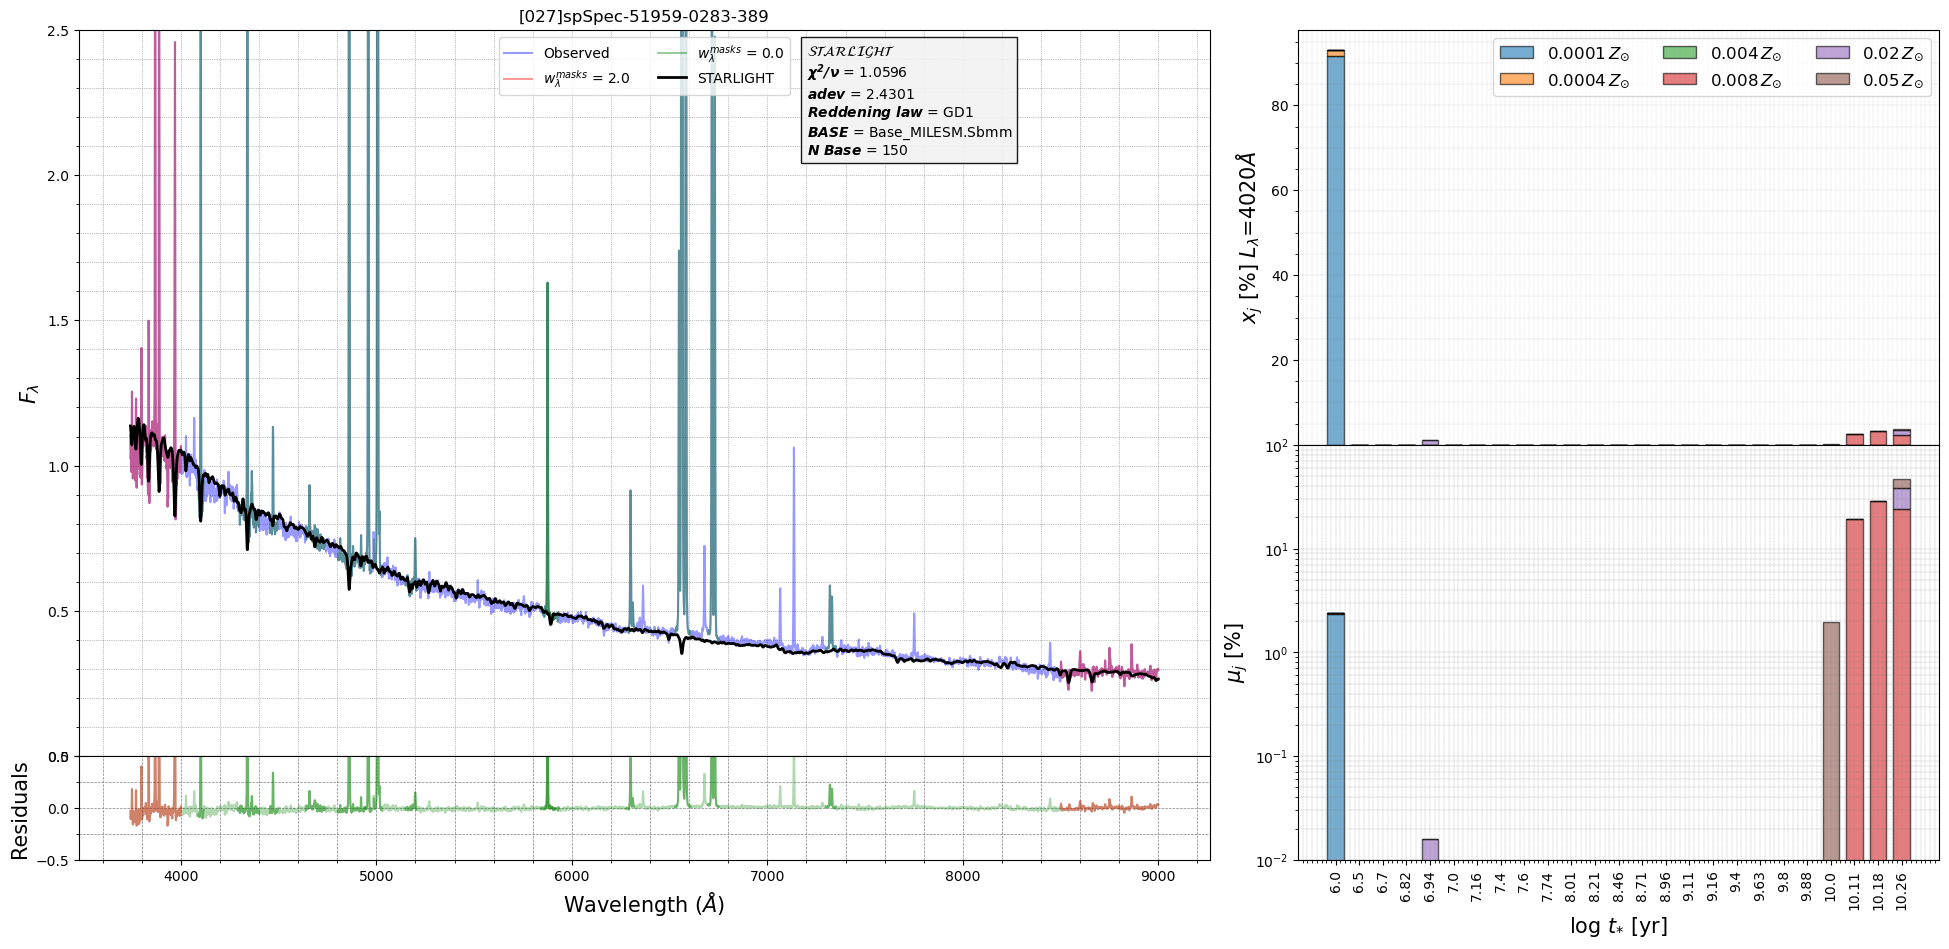

In [71]:
spec_pop_STAR(id = '[027]GD1.MILES150.fits',
            home = home,mask_loc = ['/home/holman/Starlight_masks/','[001]mskFR.txt'],Z_w = True)

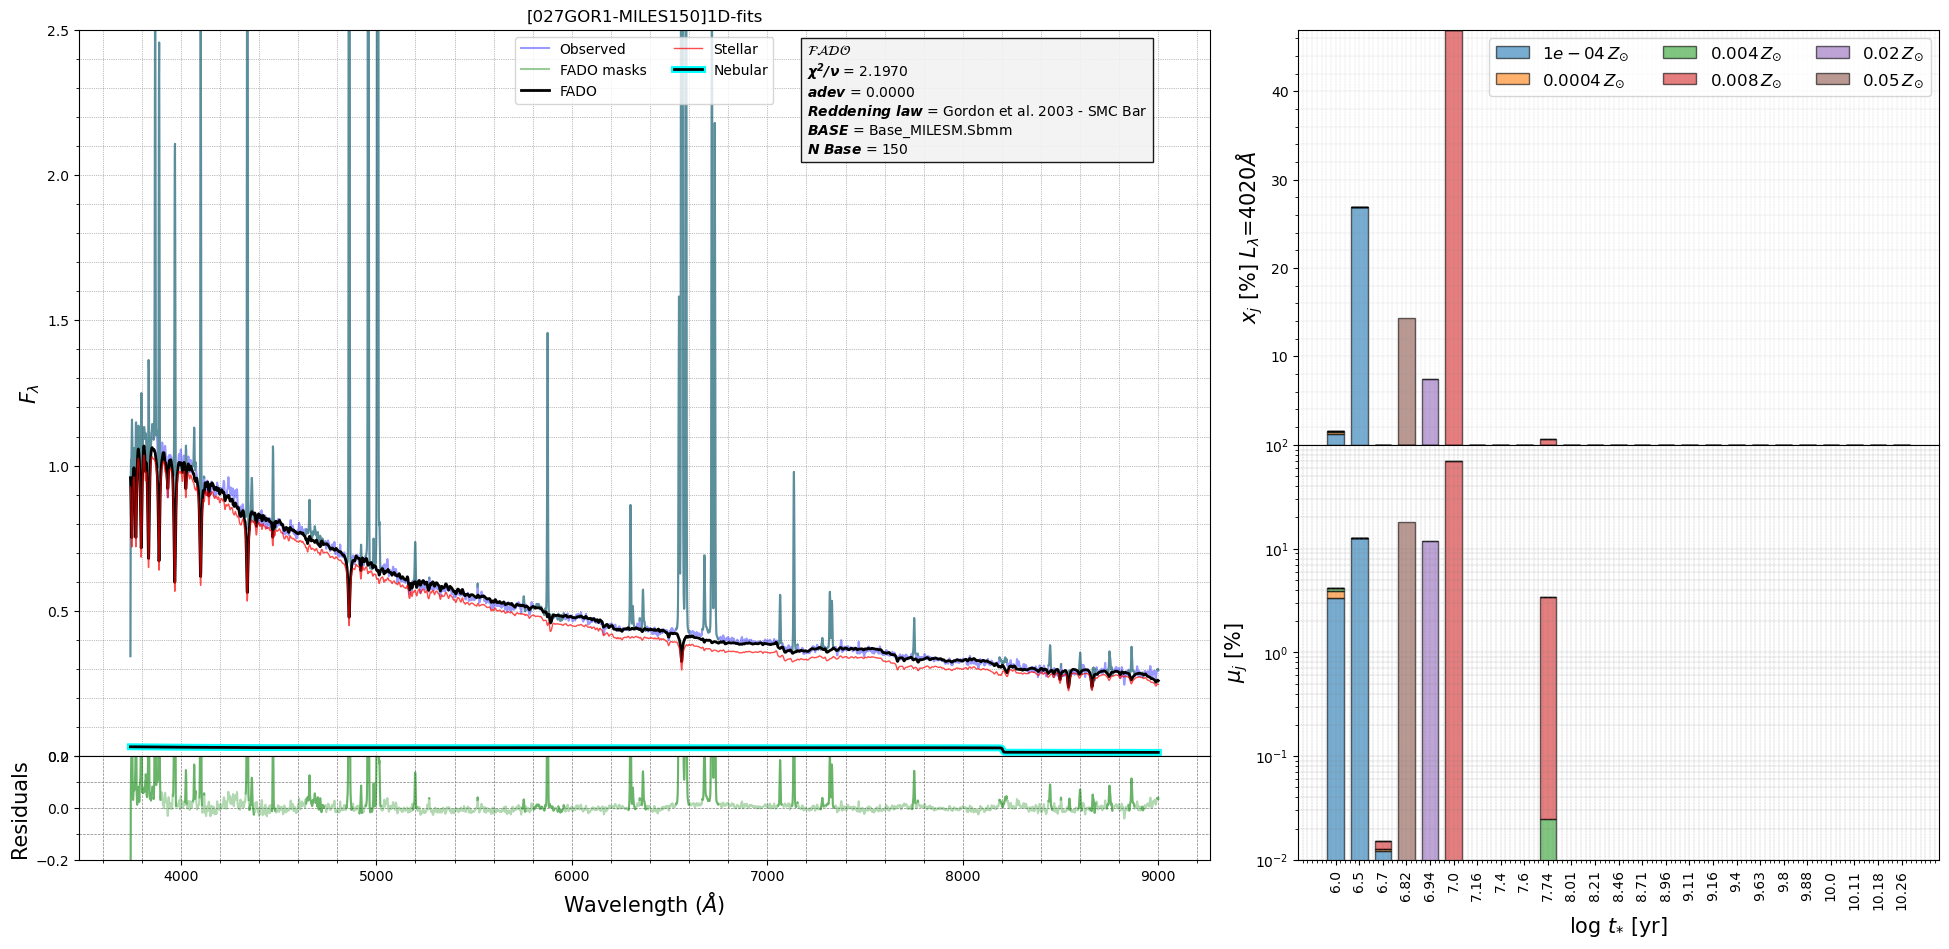

In [72]:
spec_pop_FADO(id = '027GOR1.MILES150_1D.fits',home = '/home/holman/FADOv1b/output/')

In [67]:
FITS_test = fits.open(home+'[027]GD1.MILES150.fits')

FITS_test.info()

Filename: /home/holman/StarLightv05/outputs/[027]GD1.MILES150.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       6   (1, 1)   float64   
  1  STELLAR COMPOSITION    1 BinTableHDU    105   150R x 14C   [D, D, D, D, D, D, K, D, 10A, 3A, D, D, D, D]   
  2  SPECTRUM FIT    1 BinTableHDU     25   5259R x 5C   [D, D, D, D, D]   


In [68]:
FITS_test[1].header['adev']

2.43006

In [69]:
Tabe = Table.read(FITS_test[2])
Tube = Tabe[(Tabe['f_obs']>0) & (Tabe['wei']>0)]
AdEv = abs(Tube['f_obs']-Tube['f_syn']) / Tube['f_obs'] 
AdEv = (np.sum(AdEv) / len(Tube)) * 100
AdEv

2.4300579941201272

In [75]:
FITS_test = fits.open('/home/holman/FADOv1b/output/' +'027GOR1.MILES150_1D.fits')

FITS_test.info()

spec_data = FITS_test[0].data
no_false = spec_data[0]!=0.0

Filename: /home/holman/FADOv1b/output/027GOR1.MILES150_1D.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      56   (5759, 19)   float32   


In [19]:
Lib_exp_home = os.path.expanduser("~") + '/FADOv1b/SSPs/MILES_library_v9.1_ASCII/'

lib_list = os.listdir(Lib_exp_home)

#lib_list.remove('Base.MILES_whole')

lib_list.sort()

len(lib_list)


986

In [ ]:

Lib_exp_home = os.path.expanduser("~") + '/gdrive/DataHII/BASES/MILESM.Sbmm/'

lib_list = os.listdir(Lib_exp_home)

lib_list.remove('Base_MILESM.Sbmm')

lib_list.sort()

len(lib_list)


3466

In [10]:
data

spec-names,age(yr),met,SSP_code,M_star0,---,alpha_Fe
str38,float64,float64,str10,float64,int64,float64
bc2003_hr_milesm_m22_chab_ssp_020.spec,1000000.0,0.0001,age020_m22,1.0,0,0.0
bc2003_hr_milesm_m22_chab_ssp_045.spec,3160000.0,0.0001,age045_m22,1.0,0,0.0
bc2003_hr_milesm_m22_chab_ssp_055.spec,5010000.0,0.0001,age055_m22,0.9582,0,0.0
bc2003_hr_milesm_m22_chab_ssp_061.spec,6610000.0,0.0001,age061_m22,0.9297,0,0.0
bc2003_hr_milesm_m22_chab_ssp_067.spec,8710000.0,0.0001,age067_m22,0.903,0,0.0
bc2003_hr_milesm_m22_chab_ssp_070.spec,10000000.0,0.0001,age070_m22,0.8902,0,0.0
bc2003_hr_milesm_m22_chab_ssp_078.spec,14450000.0,0.0001,age078_m22,0.8589,0,0.0
bc2003_hr_milesm_m22_chab_ssp_090.spec,25120000.0,0.0001,age090_m22,0.8174,0,0.0
bc2003_hr_milesm_m22_chab_ssp_104.spec,40000000.0,0.0001,age104_m22,0.783,0,0.0


In [81]:
len(np.unique(data['age(yr)']))

25

bc2003_hr_milesm_m22_chab_ssp_020.spec
bc2003_hr_milesm_m32_chab_ssp_020.spec
bc2003_hr_milesm_m42_chab_ssp_020.spec
bc2003_hr_milesm_m52_chab_ssp_020.spec
bc2003_hr_milesm_m62_chab_ssp_020.spec
bc2003_hr_milesm_m72_chab_ssp_020.spec


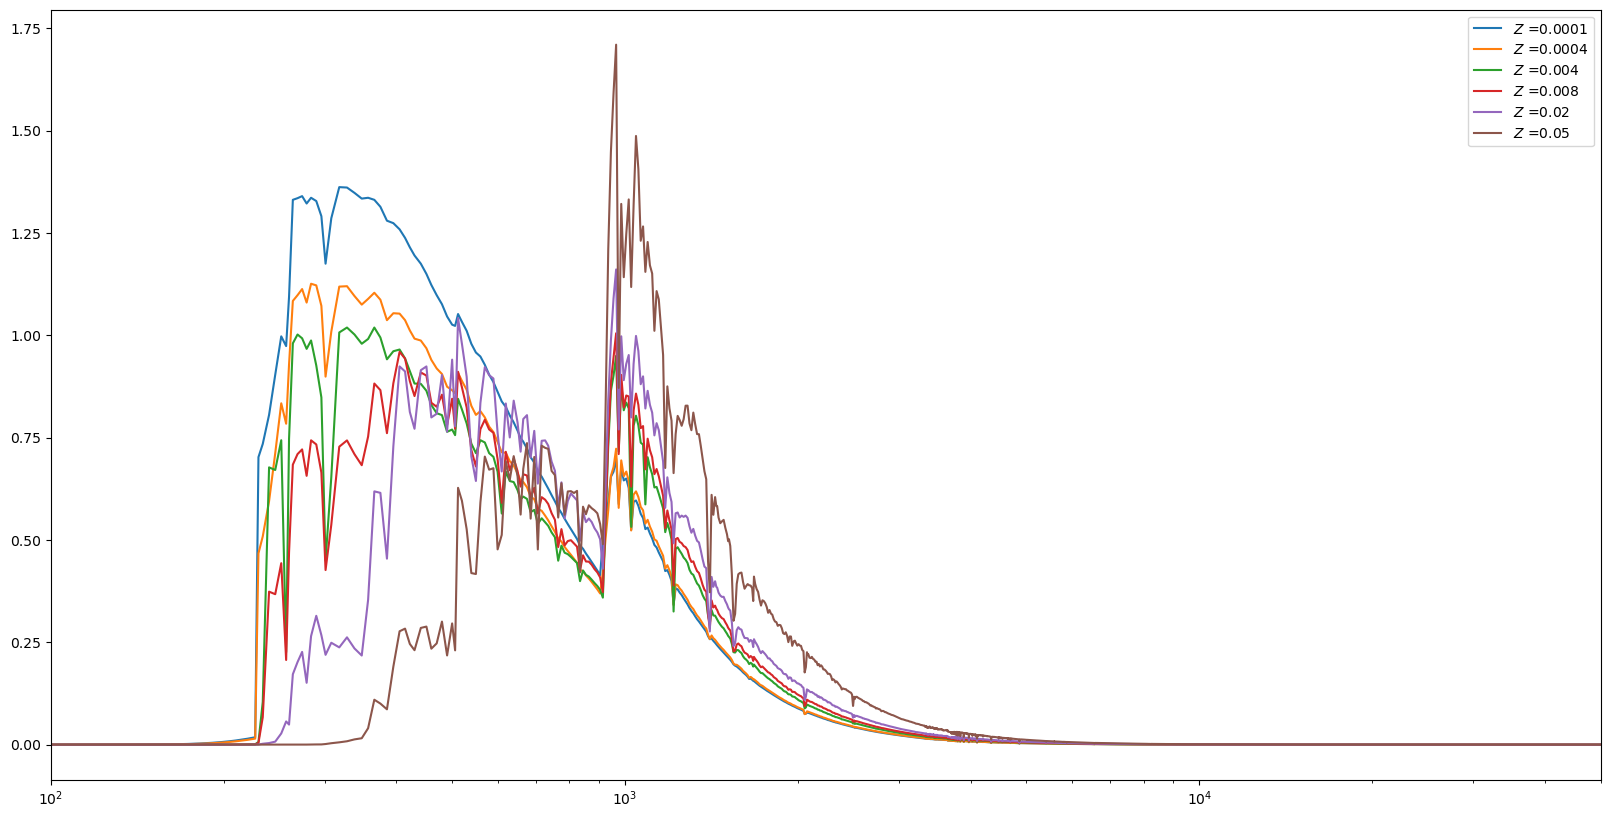

In [80]:
from astropy.io import ascii
data = ascii.read(os.path.expanduser("~") + '/gdrive/DataHII/BASES/Base_MILESM_toread', header_start = 0)


fig = plt.figure(figsize=(20, 10))

ax1 = fig.add_subplot()

for i in range(len(data)):#

    edad = data['age(yr)'][i]

    if (edad == 1000000.0):  

        print(data['spec-names'][i])
    
        spec = ascii.read(os.path.expanduser("~") + '/gdrive/DataHII/BASES/MILESM.Sbmm/' + str(data['spec-names'][i]), data_start = 0, names = ['Lambda','Flux'])

        metal = str(data['met'][i])

        ax1.plot(spec['Lambda'],spec['Flux'], label = fr'$Z$ ={metal}')
        ax1.set_xlim(100,50000)
        ax1.set_xscale('log')
        ax1.legend()



        del spec

#, Met={data['met'][i]}, Mstar={data['M_star'][i]}

In [119]:
6*4*6

144

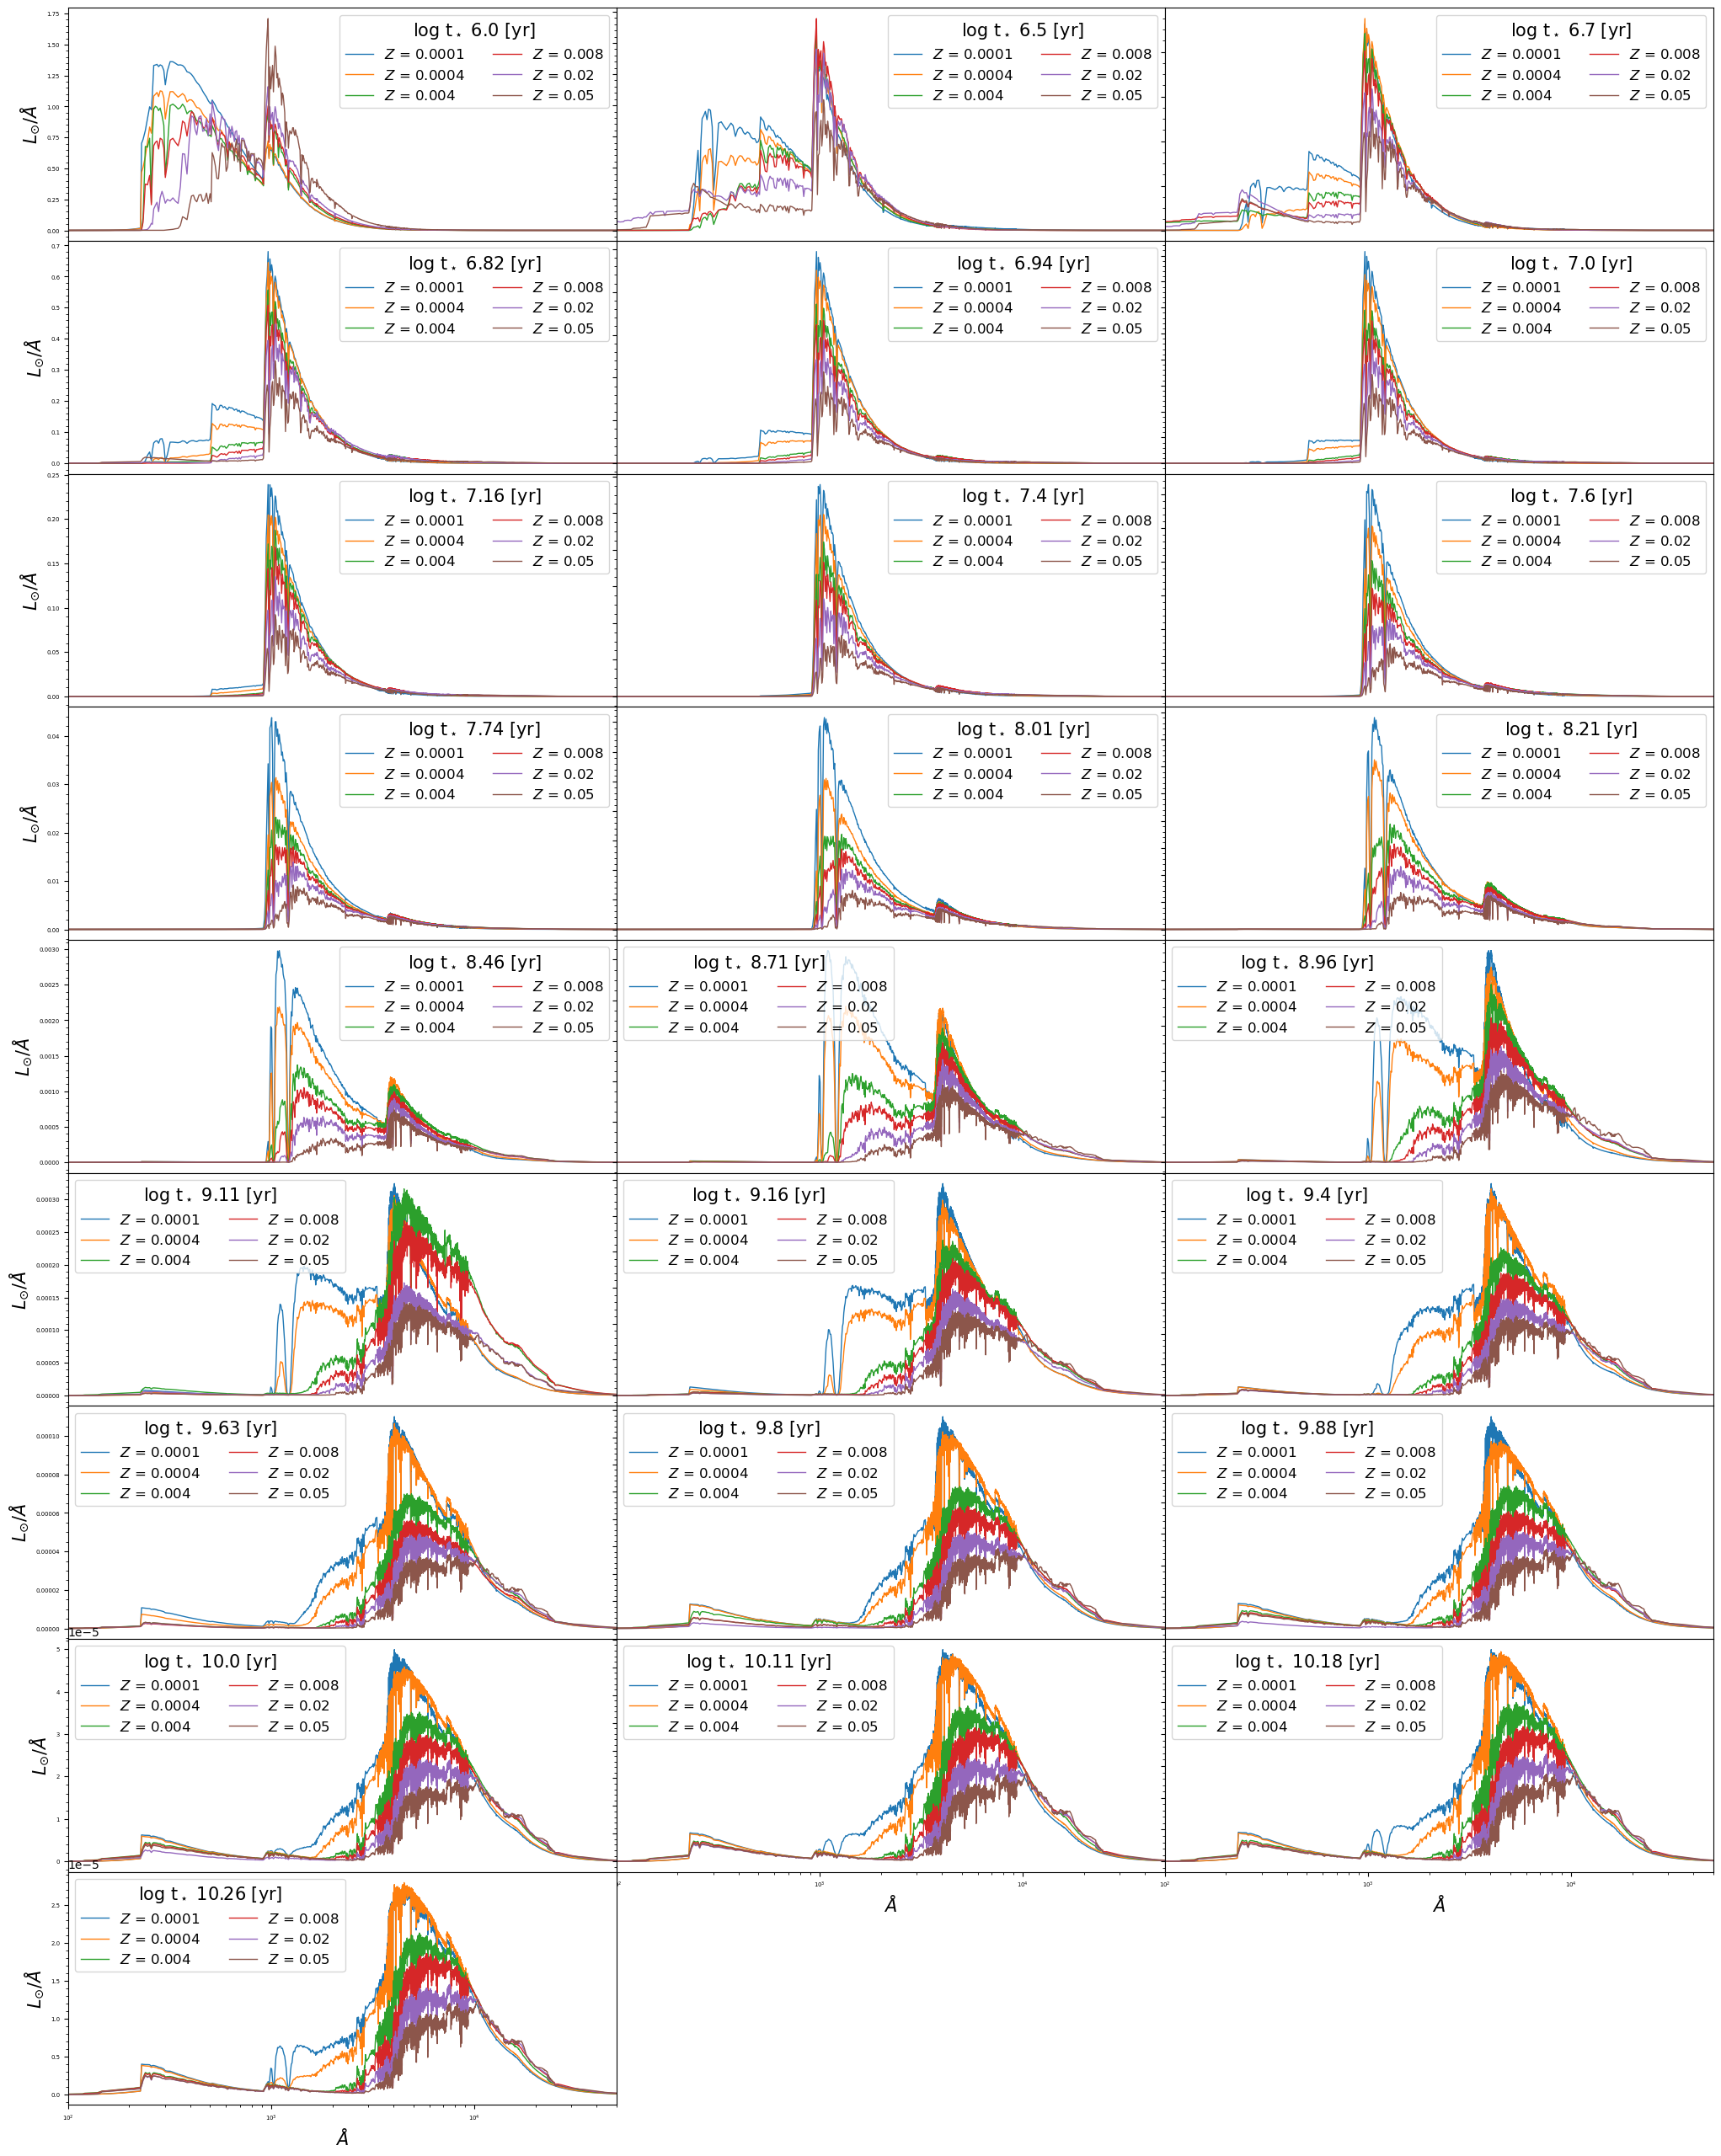

In [138]:
data = ascii.read(os.path.expanduser("~") + '/gdrive/DataHII/BASES/Base_MILESM_toread', header_start = 0)

fig = plt.figure(figsize=(21, 30))

gs = gridspec.GridSpec(
    9, 3,
    figure=fig,
    width_ratios=[1, 1,1],
    height_ratios=[1, 1,1,1,1,1,1,1,1],
    wspace=0.0,
    hspace=0.0
)

gs.update(left=0.05, bottom=0.05, right=0.98, hspace=0.0)


edades =np.unique(data['age(yr)'])


def ax_function(x,y,edad):

    ax = fig.add_subplot(gs[x, y])

    for i in range(len(data)):
        edad_spec = data['age(yr)'][i]
        if (edad_spec == edad):
            spec = ascii.read(os.path.expanduser("~") + '/gdrive/DataHII/BASES/MILESM.Sbmm/' + str(data['spec-names'][i]), data_start = 0, names = ['Lambda','Flux'])
            metal = str(data['met'][i])
            ax.plot(spec['Lambda'],spec['Flux'], label = fr'$Z$ = {metal}',linewidth = 1)

    edad_title = round(np.log10(edad),2)

    ax.minorticks_on()
    ax.tick_params(labelleft=False,labelbottom=False)
    ax.set_xlim(100,50000)
    ax.set_xscale('log')
    #ax.set_title(f"{edad_title} [Myr]",pad=-600,loc="center")
    ax.legend(ncol=2,title_fontsize=15, fontsize=12,title = fr"log t$_\star$ {edad_title} [yr]")

    return ax


ax0 = ax_function(0,0,edades[0])
ax0.set_ylabel(r'$L_{\odot}$/$\AA$', fontsize=15)
ax0.tick_params(left=True,labelleft=True, labelsize=5)
ax1 = ax_function(0,1,edades[1])
ax2 = ax_function(0,2,edades[2])

ax3 = ax_function(1,0,edades[3])
ax3.set_ylabel(r'$L_{\odot}$/$\AA$', fontsize=15)
ax3.tick_params(left=True,labelleft=True, labelsize=5)
ax4 = ax_function(1,1,edades[4])
ax5 = ax_function(1,2,edades[5])

ax6 = ax_function(2,0,edades[6])
ax6.set_ylabel(r'$L_{\odot}$/$\AA$', fontsize=15)
ax6.tick_params(left=True,labelleft=True, labelsize=5)
ax7 = ax_function(2,1,edades[7])
ax8 = ax_function(2,2,edades[8])

ax9 = ax_function(3,0,edades[9])
ax9.set_ylabel(r'$L_{\odot}$/$\AA$', fontsize=15)
ax9.tick_params(left=True,labelleft=True, labelsize=5)
ax10 = ax_function(3,1,edades[10])
ax11 = ax_function(3,2,edades[11])

ax12 = ax_function(4,0,edades[12])
ax12.set_ylabel(r'$L_{\odot}$/$\AA$', fontsize=15)
ax12.tick_params(left=True,labelleft=True, labelsize=5)
ax13 = ax_function(4,1,edades[13])
ax14 = ax_function(4,2,edades[14])

ax15 = ax_function(5,0,edades[15])
ax15.set_ylabel(r'$L_{\odot}$/$\AA$', fontsize=15)
ax15.tick_params(left=True,labelleft=True, labelsize=5)
ax16 = ax_function(5,1,edades[16])
ax17 = ax_function(5,2,edades[17])

ax18 = ax_function(6,0,edades[18])
ax18.set_ylabel(r'$L_{\odot}$/$\AA$', fontsize=15)
ax18.tick_params(left=True,labelleft=True, labelsize=5)
ax19 = ax_function(6,1,edades[19])
ax20 = ax_function(6,2,edades[20])

ax21 = ax_function(7,0,edades[21])
ax21.set_ylabel(r'$L_{\odot}$/$\AA$', fontsize=15)
ax21.tick_params(left=True,labelleft=True, labelsize=5)
ax22 = ax_function(7,1,edades[22])
ax22.set_xlabel(r'$\AA$', fontsize=15)
ax22.tick_params(bottom=True,labelbottom=True, labelsize=5)
ax23 = ax_function(7,2,edades[23])
ax23.set_xlabel(r'$\AA$', fontsize=15)
ax23.tick_params(bottom=True,labelbottom=True, labelsize=5)

ax24 = ax_function(8,0,edades[24])
ax24.set_ylabel(r'$L_{\odot}$/$\AA$', fontsize=15)
ax24.set_xlabel(r'$\AA$', fontsize=15)
ax24.tick_params(left=True,labelleft=True, labelsize=5)
ax24.tick_params(bottom=True,labelbottom=True, labelsize=5)




In [142]:
path = '/home/holman/gdrive/DataHII/BibRefs/'

GEHR_Table = pd.read_csv('/home/holman/gdrive/DataHII/SPS/GEHRs_finalList.csv')

for b in range(len(GEHR_Table)):
    if b >= 15:
        print(GEHR_Table['name'].iloc[b])
        os.mkdir(path + '/' + str(GEHR_Table['name'].iloc[b]) + '/')



NGC1073
NGC2500
NGC3184
MESSIER096
NGC3370
MESSIER066
NGC4214
NGC4414
NGC4496
NGC4535
NGC4536
NGC4725
UGC08091
NGC5204
UGC09128
NGC5584


In [141]:
GEHR_Table

,n,name,ra,dec,z,No.GEHRs,status,Cefeidas,TRGB,RRLyrae,MEGARA
0,0,LMC,80.89417,-69.75611,0.000927,1,Módulo calibrado,183,13,80,0
1,1,IC0010,5.07205,59.30385,-0.001161,2,Módulo calibrado,1,10,1,0
2,2,MESSIER033,23.46204,30.66022,-0.000598,4,Módulo calibrado,28,22,6,1
3,3,MESSIER081,148.88822,69.06529,-0.000130,2,Módulo calibrado,24,14,0,1
4,4,MESSIER101,210.80227,54.34895,0.000804,5,Módulo calibrado,29,18,0,1
5,5,MRK0116,143.50845,55.24107,0.002505,1,Módulo calibrado,4,3,0,1
6,6,NGC0925,36.82016,33.57912,0.001845,3,Módulo calibrado,21,0,0,0
7,7,NGC2366,112.22542,69.21497,0.000344,4,Módulo calibrado,1,7,0,0
8,8,NGC2403,114.21374,65.60268,0.000445,3,Módulo calibrado,5,7,0,1
9,9,NGC2541,123.66728,49.06193,0.001828,4,Módulo calibrado,17,0,0,1


([], [])

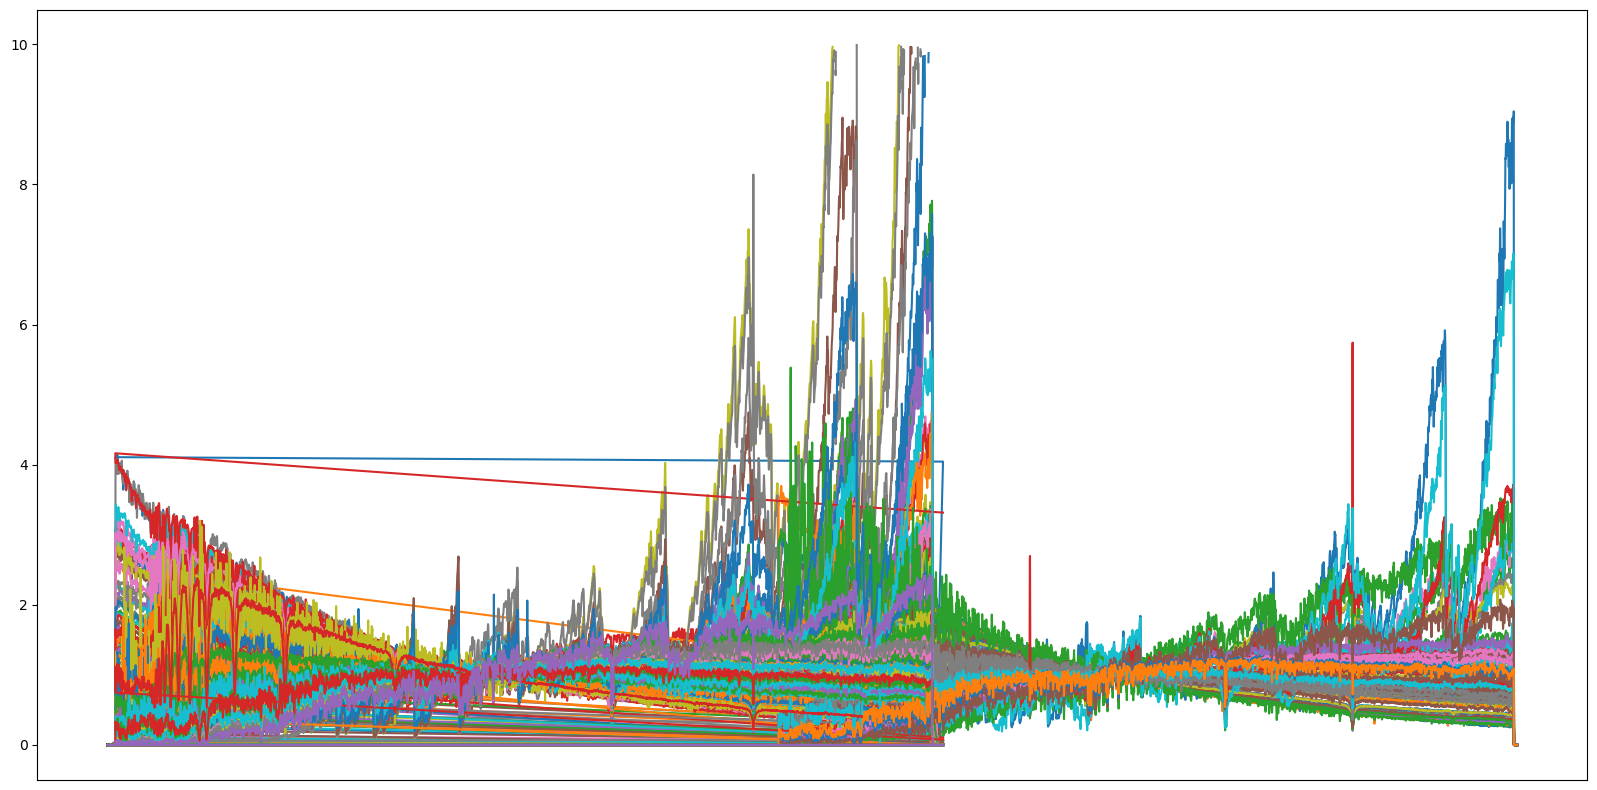

In [12]:
fig = plt.figure(figsize=(20, 10))
for i in lib_list:
    DF = pd.read_csv(Lib_exp_home+i,header = None, sep ='     ',engine = 'python',names = ['lambda','flux'])
    L = np.array(DF['lambda'])
    F = np.array(DF['flux'])
    plt.plot(L,F)
    del DF,L,F
plt.xticks([])